In [1]:
import numpy as np
import pandas as pd
from sklearn import metrics
from openpyxl import load_workbook
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import multiprocessing
import os
import time
import gloce as gc
from osgeo import gdal
from osgeo import gdalconst
from mpl_toolkits.basemap import Basemap
from glob import glob
from math import ceil
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
#return im_data, im_width, im_height, im_geotrans, im_proj
def read_img(filename):
    dt = gdal.Open(filename)
    im_width = dt.RasterXSize
    im_height = dt.RasterYSize
    im_bands = dt.RasterCount
    im_geotrans = dt.GetGeoTransform()
    im_proj = dt.GetProjection()
    im_data = dt.ReadAsArray(0,0,im_width,im_height)
    return im_data, im_width, im_height, im_geotrans, im_proj
def write_img(filename, im_proj, im_geotrans, im_data):
    if 'int8' in im_data.dtype.name:
        datatype = gdal.GDT_Byte
    elif 'int16' in im_data.dtype.name:
        datatype = gdal.GDT_UInt16
    else:
        datatype = gdal.GDT_Float32
    if len(im_data.shape) == 3:
        im_bands, im_height, im_width = im_data.shape
    else:
        im_bands, (im_height, im_width) = 1, im_data.shape
    driver = gdal.GetDriverByName("GTiff")
    dataset = driver.Create(filename, im_width, im_height, im_bands, datatype)
    dataset.SetGeoTransform(im_geotrans)
    dataset.SetProjection(im_proj)
    if im_bands == 1:
        dataset.GetRasterBand(1).WriteArray(im_data)
    else:
        for i in range(im_bands):
            dataset.GetRasterBand(i + 1).WriteArray(im_data[i])
spei_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/'
drv_path='//weili/User2/mxsun/CESS_230818/Pattern_drive/'
bias_path='//weili/User2/mxsun/CESS_230818/bias_variable/'

In [10]:
import numpy as np
import pandas as pd
from sklearn import metrics
from openpyxl import load_workbook
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import multiprocessing
import os
import time
import gloce as gc
from osgeo import gdal
from osgeo import gdalconst
from mpl_toolkits.basemap import Basemap
from glob import glob
from math import ceil
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
#return im_data, im_width, im_height, im_geotrans, im_proj
def read_img(filename):
    dt = gdal.Open(filename)
    im_width = dt.RasterXSize
    im_height = dt.RasterYSize
    im_bands = dt.RasterCount
    im_geotrans = dt.GetGeoTransform()
    im_proj = dt.GetProjection()
    im_data = dt.ReadAsArray(0,0,im_width,im_height)
    return im_data, im_width, im_height, im_geotrans, im_proj
def write_img(filename, im_proj, im_geotrans, im_data):
    if 'int8' in im_data.dtype.name:
        datatype = gdal.GDT_Byte
    elif 'int16' in im_data.dtype.name:
        datatype = gdal.GDT_UInt16
    else:
        datatype = gdal.GDT_Float32
    if len(im_data.shape) == 3:
        im_bands, im_height, im_width = im_data.shape
    else:
        im_bands, (im_height, im_width) = 1, im_data.shape
    driver = gdal.GetDriverByName("GTiff")
    dataset = driver.Create(filename, im_width, im_height, im_bands, datatype)
    dataset.SetGeoTransform(im_geotrans)
    dataset.SetProjection(im_proj)
    if im_bands == 1:
        dataset.GetRasterBand(1).WriteArray(im_data)
    else:
        for i in range(im_bands):
            dataset.GetRasterBand(i + 1).WriteArray(im_data[i])
spei_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/'
sm_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/RF/'
soil_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/RF/'
drv_path='//weili/User2/mxsun/CESS_230818/Pattern_drive/'
era5_path='//weili/User2/mxsun/CESS_230818/precipitation/'
bias_path='//weili/User2/mxsun/CESS_230818/bias_variable/'

In [5]:
treeH = read_img(spei_path+'African_th2019_001_230525.tif')[0]
print("treeH:",treeH.min(),treeH.max())
tc_planet = read_img(spei_path+'Africa_tc2019_mosaic_001_fillNaN_231215.tif')[0]
print("tc_planet:",tc_planet.min(),tc_planet.max())

treeH: 0.0 37.440773
tc_planet: 0 216


In [6]:
treeH[treeH==0]=np.nan
tc_planet=tc_planet.astype(np.float32)
tc_planet[tc_planet==0]=np.nan
tc_planet[tc_planet>100]=np.nan

In [7]:
DEAA=read_img(spei_path+'SPEI_deaa001_240504.tif')[0]
DAA=read_img(spei_path+'SPEI_daa001_240504.tif')[0]
DAA[DAA==1]=2
ele_range=DEAA+DAA
ele_range[ele_range==0]=np.nan
np.nanmin(ele_range),np.nanmax(ele_range)

(1.0, 2.0)

In [8]:
hfp = read_img(spei_path+'hfp2018_Afirca_001_230525.tif')[0]
print('hfp',np.nanmin(hfp),np.nanmax(hfp))

hfp 0.0 50.0


In [11]:
dem=read_img(spei_path+'gtopoDEM_afr_001.tif')[0]
slope=read_img(spei_path+'gtopoSlope_afr_001.tif')[0]
print('dem',dem.min(),dem.max())
print('slope',slope.min(),slope.max())
dem=dem.astype(np.float32)
dem[dem==-9999]=np.nan
slope[slope<0]=np.nan

road_density=read_img(bias_path+'grip4_density_total_af_001_241219.tif')[0]
road_density=road_density/1000#单位从m转为km
road_density=np.where((road_density >= 0)&(road_density < 10), road_density, np.nan)
print(road_density.min(),road_density.max())
river=read_img(bias_path+'HydroRIVERS_v10_af_001_241219.tif')[0]
river = np.where(river > 0, 1, 0)
print(river.min(),river.max())
fragmentation=read_img(bias_path+'FFI2020_af_001_241219.tif')[0]
fragmentation=np.where(fragmentation > 0, fragmentation, 0)
print(fragmentation.min(),fragmentation.max())
fire_times=read_img(bias_path+'CCI_fire_times_001_241219.tif')[0]
print(fire_times.min(),fire_times.max())

era5_precipitation=read_img(era5_path+'Precipitation_ERA5_1516_001sub_241216.tif')[0]
#目前单位时mm/month,改为mm/yr根GPM数据一致
era5_precipitation=era5_precipitation*12
print("treeH:",era5_precipitation.min(),era5_precipitation.max())

dem -9999 5438
slope -3.402823e+38 79.12291
nan nan
0 1
0.0 0.99986887
0.0 6.0
treeH: nan nan


In [12]:
var_arr=np.array([treeH,tc_planet])
bias_arr=np.array([dem,slope,road_density,river,fragmentation,fire_times,era5_precipitation])
bias_arr.shape

(7, 6500, 7900)

# slide with andam's method

In [21]:
#随机提取3*3矩阵
def random_plot(mask_dis, num_plots=200, plot_size=(3, 3), random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
    # 获取掩码数组的形状
    rows, cols = mask_dis.shape
    plot_rows, plot_cols = plot_size
    # 生成所有可能的地块左上角位置
    possible_locations = [(r, c) for r in range(rows - plot_rows + 1) for c in range(cols - plot_cols + 1)]
    # 随机选择不重复的位置
    if len(possible_locations) < num_plots:
        raise ValueError("可用地块数量不足，请检查窗口大小或地块大小。")
    selected_locations = np.random.choice(len(possible_locations), size=num_plots, replace=False)
    plot_locations = [possible_locations[idx] for idx in selected_locations]
    return plot_locations

# Covariate matching

In [186]:
# current shape:(6500,7900)
from scipy.spatial.distance import mahalanobis
def slide_window_mean(s,n_var,rg,res_var,res_cor):

    """
    s:窗口大小，n_var:numbers of variable, rg:mask of elephant area,1-2, res_var:array of variables, res_cor, array of covariates
    """
    mks=np.ones((6500,7900))
    deaa_var_unmatch=np.zeros((n_var,32,39))
    daa_var_unmatch=np.zeros((n_var,32,39))
    dif_var_unmatch=np.zeros((n_var,32,39))
    deaa_var_match=np.zeros((n_var,32,39))
    daa_var_match=np.zeros((n_var,32,39))
    dif_var_match=np.zeros((n_var,32,39))

    n_plots_deaa_unmatch=np.zeros((32,39))
    n_plots_daa_unmatch=np.zeros((32,39))
    n_plots_match=np.zeros((32,39))
    for i in range(32):
        for j in range(39):
            mask_dis=mks[i*s:(i+1)*s,j*s:(j+1)*s]
            ele_dis=rg[i*s:(i+1)*s,j*s:(j+1)*s]
            res_var_dis=res_var[:,i*s:(i+1)*s,j*s:(j+1)*s]#变量，三维矩阵
            res_cor_dis=res_cor[:,i*s:(i+1)*s,j*s:(j+1)*s]#协变量，用于计算马氏距离，三维矩阵
            #循环创建200个3*3的plot
            var_deaa_pool=[]#行数：plots,列数：variables
            var_daa_pool=[]
            cor_deaa_pool=[]#行数：plots,列数：covariates
            cor_daa_pool=[]
            n_deaa_unmatch=0
            n_daa_unmatch=0
            n_match=0
            plot_locations =random_plot(mask_dis, num_plots=200, plot_size=(3, 3), random_seed=42)#random_seed固定保证实验可复制
            for r,c in plot_locations:
                tt_ele=ele_dis[r:r + 3, c:c + 3]
                var_tt=res_var_dis[:, r:r + 3, c:c + 3]
                cor_tt=res_cor_dis[:, r:r + 3, c:c + 3]
                #if np.count_nonzero(~np.isnan(tt_ele))>5:#保证plot中大部份值有效
                #有象区和无象区认领plots
                if np.nanmean(tt_ele)==1:
                    var_deaa_pool.append(np.nanmean(var_tt,axis=(1,2)))#每个变量在该地块中的均值
                    cor_deaa_pool.append(np.nanmean(cor_tt,axis=(1,2)))
                    n_deaa_unmatch+=1
                elif np.nanmean(tt_ele)==2:
                    var_daa_pool.append(np.nanmean(var_tt,axis=(1,2)))
                    cor_daa_pool.append(np.nanmean(cor_tt,axis=(1,2)))
                    n_daa_unmatch+=1
                #如果plot mask的均值位于1-2，则处于有象区和无象区交界的区域，剔除
            n_plots_deaa_unmatch[i,j]=n_deaa_unmatch
            n_plots_daa_unmatch[i,j]=n_daa_unmatch
            #unmatch部分的mean和diff---------------------------------
            if len(var_deaa_pool)>0 and len(var_daa_pool)>0:
                deaa_var_unmatch[:,i,j]=np.nanmean(var_deaa_pool,axis=0)#[variable, rows, cols]
                daa_var_unmatch[:,i,j]=np.nanmean(var_daa_pool,axis=0)
                dif_var_unmatch[:,i,j]=deaa_var_unmatch[:,i,j]-daa_var_unmatch[:,i,j]
            else:
                deaa_var_unmatch[:,i,j]=np.nan#[variable, rows, cols]
                daa_var_unmatch[:,i,j]=np.nan
                dif_var_unmatch[:,i,j]=np.nan
            #matching-----------------------------------------------
            #计算协变量的Mahalanobis distances
            if len(cor_deaa_pool)>0 and len(cor_daa_pool)>1:
                cov_matrix = np.cov(np.array(cor_daa_pool).T)#计算plots之间的协方差
                det_val = np.linalg.det(cov_matrix)
                if abs(det_val) < 1e-6:
                    # 对角线加扰动
                    alpha = 1e-3
                    cov_matrix += alpha * np.eye(cov_matrix.shape[0])
                inv_cov_matrix = np.linalg.inv(cov_matrix)#计算协方差矩阵的逆矩阵
                print("Covariance calculated")
                matched_deaa_vars = []
                matched_daa_vars  = []
                for match_cor_deaa, match_var_deaa in zip(cor_deaa_pool, var_deaa_pool):
                    dist_pool=[]#每一个有象区的plots找2个马氏距离最近的无象区的plots
                    for match_cor_daa, match_var_daa in zip(cor_daa_pool, var_daa_pool):
                        dist = mahalanobis(match_cor_deaa, match_cor_daa, inv_cov_matrix)#计算有象无象区plots协变量的马氏距离
                        dist_pool.append((dist, match_var_deaa, match_var_daa))
                    # 如果 distances 为空，就跳过
                    if not dist_pool:
                        continue
                    dist_pool.sort(key=lambda x:x[0])
                    #取距离最近的2个
                    if len(dist_pool) >= 2:
                        top_2 = dist_pool[:2]
                        n_match+=2
                    else:
                        top_2 = dist_pool
                        n_match+=1
                    for (dist_val, best_deaa_vars, best_daa_vars) in top_2:
                        matched_deaa_vars.append(best_deaa_vars)  # best_deaa_vars shape: (n_var, )
                        matched_daa_vars.append(best_daa_vars)    # best_daa_vars shape: (n_var, )
                n_plots_match[i, j] = n_match
                if len(matched_deaa_vars) > 0:
                    deaa_var_match[:, i, j] = np.nanmean(matched_deaa_vars, axis=0)
                    daa_var_match[:, i, j]  = np.nanmean(matched_daa_vars, axis=0)
                    dif_var_match[:, i, j]  = deaa_var_match[:, i, j] - daa_var_match[:, i, j]
                else:
                    deaa_var_match[:, i, j] = np.nan
                    daa_var_match[:, i, j]  = np.nan
                    dif_var_match[:, i, j]  = np.nan
            else:
                # 如果 match_daa_plots_cor <= 1, 就没有可配对
                deaa_var_match[:, i, j] = np.nan
                daa_var_match[:, i, j]  = np.nan
                dif_var_match[:, i, j]  = np.nan
    return (deaa_var_unmatch, daa_var_unmatch, dif_var_unmatch,
            deaa_var_match, daa_var_match, dif_var_match, [n_plots_deaa_unmatch,n_plots_daa_unmatch,n_plots_match])


In [187]:
tt=slide_window_mean(200,2,ele_range,var_arr,bias_arr)
tt[0]

C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:41: RuntimeWarning: Mean of empty slice
  if np.nanmean(tt_ele)==1:
C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:45: RuntimeWarning: Mean of empty slice
  elif np.nanmean(tt_ele)==2:
C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:46: RuntimeWarning: Mean of empty slice
  var_daa_pool.append(np.nanmean(var_tt,axis=(1,2)))
C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:47: RuntimeWarning: Mean of empty slice
  cor_daa_pool.append(np.nanmean(cor_tt,axis=(1,2)))
C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:42: RuntimeWarning: Mean of empty slice
  var_deaa_pool.append(np.nanmean(var_tt,axis=(1,2)))#每个变量在该地块中的均值
C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:55: RuntimeWarning: Mean of empty slice
  deaa_var_unmatch[:,i,j]=np.nanmean(var_deaa_pool,axis=0)#[variable, rows, cols]
C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:56: Ru

Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated


C:\Users\dess\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\linalg\linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated


C:\Users\dess\AppData\Local\Temp\ipykernel_67356\2633911866.py:43: RuntimeWarning: Mean of empty slice
  cor_deaa_pool.append(np.nanmean(cor_tt,axis=(1,2)))


Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance calculated
Covariance

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])

In [188]:
np.nanmean(tt[0][0]),np.nanmean(tt[0][1]),np.nanmean(tt[1][0]),np.nanmean(tt[1][1])

(10.08719558061825, 47.621891501032074, 7.722851362053331, 38.573035227198176)

In [189]:
np.nanmean(tt[2][0]),np.nanmean(tt[2][1]),np.nansum(tt[6][0]),np.nansum(tt[6][1])

(2.4442166058306998, 8.714786502410625, 3465.0, 17867.0)

In [190]:
np.nanmean(tt[3][0]),np.nanmean(tt[3][1]),np.nanmean(tt[4][0]),np.nanmean(tt[4][1])

(10.072071117462873, 47.54533225042479, 8.44453967721771, 40.67542915479511)

In [191]:
np.nanmean(tt[5][0]),np.nanmean(tt[5][1]),np.nansum(tt[6][2])

(1.6438849604260313, 6.844976563964571, 5980.0)

In [193]:
# 分解返回值
deaa_var_unmatch, daa_var_unmatch, dif_var_unmatch = tt[0], tt[1], tt[2]
deaa_var_match,   daa_var_match,   dif_var_match   = tt[3], tt[4], tt[5]
plots_count = tt[6]  # [n_plots_deaa_unmatch, n_plots_daa_unmatch, n_plots_match]

unmatch_result = (deaa_var_unmatch, daa_var_unmatch, dif_var_unmatch)
match_result   = (deaa_var_match,   daa_var_match,   dif_var_match)

np.save(spei_path+'Andam_unmatching_results_vegetation_250101.npy',unmatch_result)
np.save(spei_path+'Andam_matching_results_vegetation_250101.npy',match_result)
np.save(spei_path+'Andam_matching_plots_vegetation_250101.npy',plots_count)

In [18]:
#delta_TH,TC,(32,39)
unmatch_result=np.load(spei_path+'Andam_unmatching_results_vegetation_250101.npy',allow_pickle=True)
match_result=np.load(spei_path+'Andam_matching_results_vegetation_250101.npy',allow_pickle=True)
delta_umpatch=unmatch_result[2]
delta_patch=match_result[2]
delta_umpatch.shape, delta_patch.shape

((2, 32, 39), (2, 32, 39))

# Fig

In [19]:
#计算p_value
unmatch_result=np.load(spei_path+'Andam_unmatching_results_vegetation_250101.npy',allow_pickle=True)
unmatch_result_deaa=unmatch_result[0]
unmatch_result_daa=unmatch_result[1]
print(unmatch_result_deaa.shape)

def del_nan(data,data1):
    aa=np.where(np.isnan(data.ravel()))
    bb=np.where(np.isnan(data1.ravel()))
    kk=np.concatenate((aa,bb),axis=1)
    yy=np.unique(kk)
    data=np.delete(data.ravel(),yy)
    data1=np.delete(data1.ravel(),yy)
    return data, data1

pp_value_unmatch=[]#th,tc
for i in range(2):
    f_deaa=unmatch_result_deaa[i]
    f_daa=unmatch_result_daa[i]
    ddt=del_nan(f_deaa,f_daa)
    sta,p=stats.wilcoxon(ddt[0],ddt[1])
    pp_value_unmatch.append(p)
pp_value_unmatch

(2, 32, 39)


[5.8415651990519996e-09, 8.992786962630634e-08]

In [20]:
match_result=np.load(spei_path+'Andam_matching_results_vegetation_250101.npy',allow_pickle=True)
match_result_deaa=match_result[0]
match_result_daa=match_result[1]
print(match_result_deaa.shape)
pp_value_match=[]#th,tc
for i in range(2):
    f_deaa=match_result_deaa[i]
    f_daa=match_result_daa[i]
    ddt=del_nan(f_deaa,f_daa)
    sta,p=stats.wilcoxon(ddt[0],ddt[1])
    pp_value_match.append(p)
pp_value_match

(2, 32, 39)


[4.4158623917002073e-07, 2.2432593896525892e-05]

## combined with paired site method

In [13]:
# combine fig with paird site method
######################mask DEM and Slope############################
# check the Δ dem and Δ slope distribution
dem1=np.load(drv_path+'Forest-structure_DEAA_dem_0.25deg_240504.npy',allow_pickle=True)
dem2=np.load(drv_path+'Forest-structure_DAA_dem_0.25deg_240504.npy',allow_pickle=True)
dem_differ=dem1-dem2

slo1=np.load(drv_path+'Forest-structure_DEAA_slope_0.25deg_240504.npy',allow_pickle=True)
slo2=np.load(drv_path+'Forest-structure_DAA_slope_0.25deg_240504.npy',allow_pickle=True)
slo_differ=slo1-slo2

dem_differ[dem_differ<-200]=np.nan
dem_differ[dem_differ>200]=np.nan
dem_differ[~np.isnan(dem_differ)]=1
slo_differ[slo_differ<-10]=np.nan
slo_differ[slo_differ>10]=np.nan
slo_differ[~np.isnan(slo_differ)]=1
# 每一层数据位置对应,建立mask
dd_mask=np.ones((260,316))*dem_differ*slo_differ

In [14]:
res_name=['treeH','th_Lang','tc_planet','tc_Hansen10']
def del_nan(data,data1):
    aa=np.where(np.isnan(data.ravel()))
    bb=np.where(np.isnan(data1.ravel()))
    kk=np.concatenate((aa,bb),axis=1)
    yy=np.unique(kk)
    data=np.delete(data.ravel(),yy)
    data1=np.delete(data1.ravel(),yy)
    return data, data1
delta=[]
pp_value=[]
for i in range(4):
    f1=np.load(drv_path+'Forest-structure_DEAA_{}_0.25deg_240504.npy'.format(res_name[i]),allow_pickle=True)*dd_mask
    f2=np.load(drv_path+'Forest-structure_DAA_{}_0.25deg_240504.npy'.format(res_name[i]),allow_pickle=True)*dd_mask
    ff=f1-f2
    delta.append(ff)
    ddt=del_nan(f1,f2)
    sta,p=stats.wilcoxon(ddt[0],ddt[1])
    pp_value.append(p)
delta[0].shape,pp_value

((260, 316),
 [1.537306231324802e-57,
  2.0219636960702422e-60,
  1.0680559379169923e-31,
  5.187694566918788e-44])

In [15]:
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a

tree_delta=[]
for i in range(4):
    tree_delta.append(kill_nan(delta[i]))
len(tree_delta[1]),len(tree_delta[0]),len(tree_delta[2]),len(tree_delta[3])

(2919, 2742, 2843, 2890)

In [16]:
#计算标准误方法2
#res_name=['treeH','th_Lang','tc_planet','tc_Hansen10','Bio']
se=[]
for i in range(4):
    se.append(stats.sem(tree_delta[i]))
se

[0.07329907861015815,
 0.06761854951847686,
 0.25988301886130194,
 0.17005743633930054]

## fig

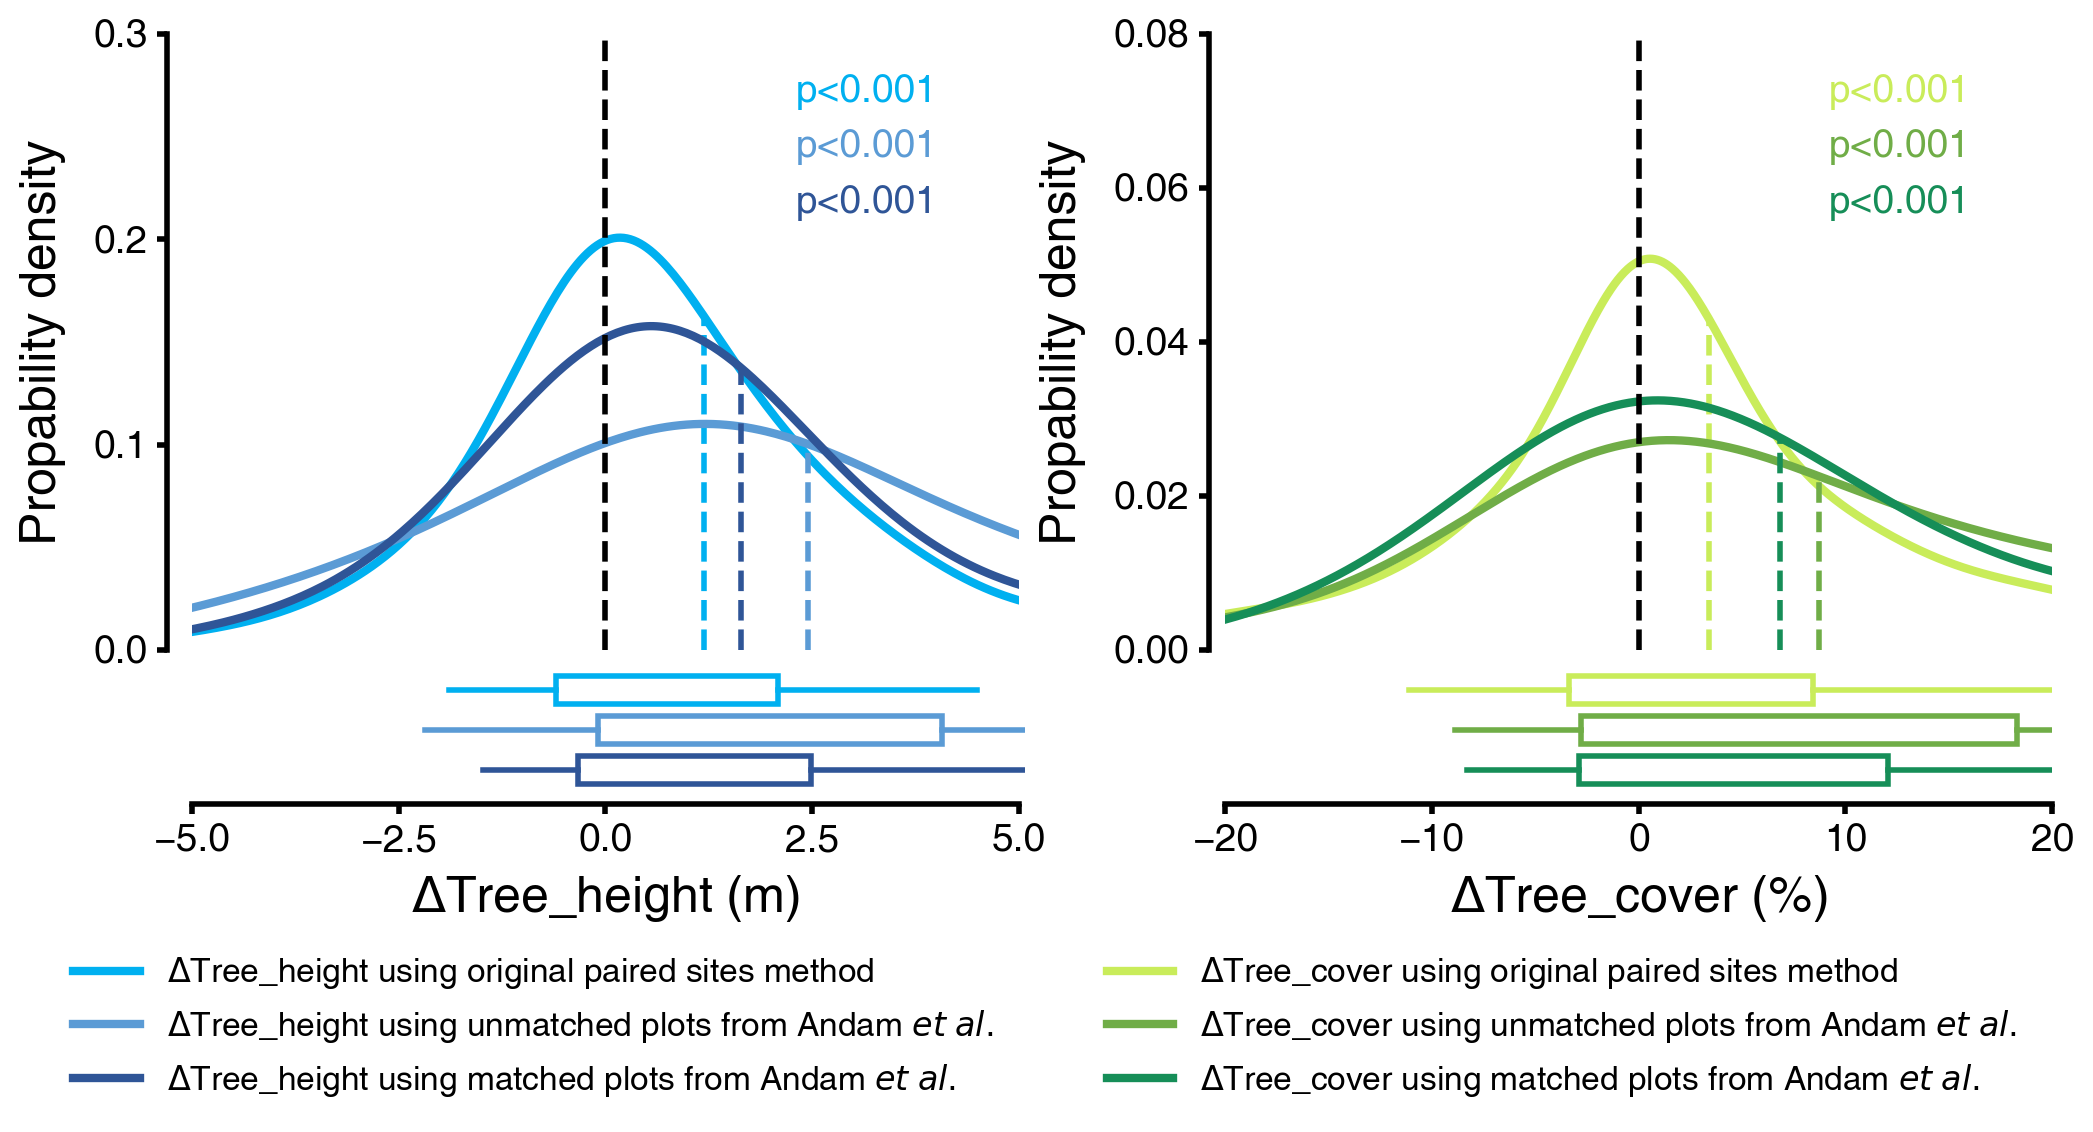

In [21]:
#data_th[paired sites, unmatch, match]

data_th=[tree_delta[0],delta_umpatch[0],delta_patch[0]]
data_pp_th=[pp_value[0],pp_value_unmatch[0],pp_value_match[0]]

data_tc=[tree_delta[2],delta_umpatch[1],delta_patch[1]]
data_pp_tc=[pp_value[2],pp_value_unmatch[1],pp_value_match[1]]

data=[data_th,data_tc]
pp=[data_pp_th,data_pp_tc]

import gloce as gc
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
fig = plt.figure(figsize=(12,4)) ##width, height default(8,6)
plt.subplots_adjust(wspace=0.25,hspace=0.2)
#fig.subplots_adjust(wspace=0.2,hspace=0.4, left=None, bottom=None, right=None, top=None)
font = {'family': 'sans-serif',
        'sans-serif': 'Helvetica',
        'weight': 'normal',
        'size': 18}
plt.rc('font', **font)  # pass in the font dict as kwargs
cl1 = np.array([(0,176,240),(91,155,213),(47,85,151)])
cl2 = np.array([(201,236,90),(112,173,71),(22,142,88)])
cl=[cl1/255,cl2/255]
#cl=['C0','salmon']
#colors = ['coral','yellowgreen','green','orange']
#lc3 = ['NF_BB','F_BB','F_NBB','NF_NBB']
#fig, axs=plt.subplots(2,2,sharex=True,sharey=True)
label1=['$\Delta$Tree_height using original paired sites method', '$\Delta$Tree_height using unmatched plots from Andam $\mathit{et}$ $\mathit{al.}$',
        '$\Delta$Tree_height using matched plots from Andam $\mathit{et}$ $\mathit{al.}$']
label2=['$\Delta$Tree_cover using original paired sites method', '$\Delta$Tree_cover using unmatched plots from Andam $\mathit{et}$ $\mathit{al.}$',
        '$\Delta$Tree_cover using matched plots from Andam $\mathit{et}$ $\mathit{al.}$']
label=[label1,label2]
tx=['(m)','(%)']
for i in range(2):
    ax = fig.add_subplot(1,2,i+1)
    for j in range(3):
        x=np.linspace(-20,20,1000)
        mean=np.nanmean(data[i][j])
        delta_rav=gc.nanravel(data[i][j])
        kenal=gaussian_kde(delta_rav)
        z=kenal.evaluate(x)
        z_mean=kenal.evaluate(mean)
        ax.plot(x,z,lw=3,color=cl[i][j],label=label[i][j])
        ax.vlines(mean,0,z_mean,lw=2,ls='--',color=cl[i][j])
        if pp[i][j]<0.001:
            #ax.text(0.73,0.89-j*0.09, '{:.2f} ***'.format(mean), fontsize=16,transform = ax.transAxes,color=cl[i][j])
            ax.text(0.73,0.89-j*0.09, 'p<0.001'.format(mean), fontsize=14,transform = ax.transAxes,color=cl[i][j])
        elif pp[i][j]<0.01:
            ax.text(0.63,0.89-j*0.1, '{:.2f} **'.format(mean), fontsize=14,transform = ax.transAxes,color=cl[i][j])
        elif pp[i][j]<0.05:
            ax.text(0.63,0.89-j*0.1, '{:.2f} *'.format(mean), fontsize=14,transform = ax.transAxes,color=cl[i][j])
        else:
            ax.text(0.63,0.89-j*0.1, '{:.3f} (p={:.2f})'.format(mean,data_pp[i]), fontsize=14,transform = ax.transAxes,color=cl[i][j])
    if i ==0:
        ax.vlines(0,0,0.3,lw=2,ls='--',color='black')
        ax.set_ylim(0,0.3)
        ax.set_yticks(np.arange(0,0.31,0.1))
        ax.set_xlim(-5,5)
        ax.set_xticks(np.arange(-5,5.1,2.5))
        ax=plt.gca()
        ax.yaxis.set_ticks_position('left')
        ax.spines['left'].set_position(('data',-5.3))
        ax.xaxis.set_ticks_position('bottom')
        ax.spines['bottom'].set_position(('data',-0.075))
        ax.set_xlabel('$\Delta$Tree_height (m)',labelpad=5)        
    else:
        ax.vlines(0,0,0.08,lw=2,ls='--',color='black')
        ax.set_ylim(0,0.08)
        ax.set_yticks(np.arange(0,0.081,0.02))
        ax.set_xlim(-20,20)
        ax.set_xticks(np.arange(-20,20.1,10))
        ax=plt.gca()
        ax.yaxis.set_ticks_position('left')
        ax.spines['left'].set_position(('data',-20.82))
        ax.xaxis.set_ticks_position('bottom')
        ax.spines['bottom'].set_position(('data',-0.020))
        ax.set_xlabel('$\Delta$Tree_cover (%)',labelpad=5)
    ax.legend(fontsize=12,loc=(-0.16,-0.75),frameon=False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('Propability density',labelpad=10)
    
    ax.xaxis.label.set_size(18)
    ax.xaxis.set_tick_params(width=2)
    
    ax.tick_params(labelsize=14)
    ax.yaxis.label.set_size(18)
    ax.yaxis.set_tick_params(width=2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    for j in range(3):
        if i ==0:
            if j ==0:
                ax1=fig.add_axes([0.122,-0,0.35,0.12])#左，底，宽，高
            elif j ==1:
                ax1=fig.add_axes([0.122,-0.05,0.35,0.12])#左，底，宽，高
            else:
                ax1=fig.add_axes([0.122,-0.1,0.35,0.12])#左，底，宽，高
            ax1.set_xlim(-5,5)
            ax1.set_xticks(np.arange(-5,5,2.5))
        if i ==1:
            if j==0:
                ax1=fig.add_axes([0.55,-0,0.35,0.12])#左，底，宽，高
            elif j==1:
                ax1=fig.add_axes([0.55,-0.05,0.35,0.12])#左，底，宽，高
            else:
                ax1=fig.add_axes([0.55,-0.1,0.35,0.12])#左，底，宽，高
            ax1.set_xlim(-20,20)
            ax1.set_xticks(np.arange(-20,20,10))
        ax1.axis('off')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_visible(False)
        ax1.tick_params(bottom=False,top=False, left=False, right=False)#隐藏刻度线
        #ax.spines['bottom'].set_visible(False)
        bplot=ax1.boxplot(gc.nanravel(data[i][j]),
                          vert=False,
                          whis=(10,90),                
                          widths=0.3,
                          patch_artist=True,
                          showmeans=False,
                          meanprops = {'marker':'o','markerfacecolor':cl[i][j],"markeredgecolor":cl[i][j],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                          medianprops={'linewidth':'0.5',"color":cl[i][j],"alpha":0},
                          boxprops={"facecolor": 'none', "edgecolor": cl[i][j],"linewidth":2,"alpha":1},
                          capprops=None,
                          whiskerprops={'linewidth':'2','color':cl[i][j]},
                          showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                          showfliers = False,
                          flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl[i][j],'color':cl[i][j]})